# SILVA Homotopy Equilibrium: Continuation Lab

This lab connects a SILVA fixed point to a continuous residual path, compares
Euler and Runge-Kutta integration with an analytic solution, and trains a small
conditioned transition. The canonical family is
`silva_homotopy_equilibrium` [46].

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [7](https://jseluis.github.io/silva-networks/paper/references/#ref-7), [46](https://jseluis.github.io/silva-networks/paper/references/#ref-46). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn

from silva_networks import (
    SILVAHomotopyEquilibrium,
    make_affine_homotopy_dataset,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(190)

## 1. Fixed-Point Residual and Classical Homotopy

For transition $T(z;x)$, define

$$
r(z;x)=z-T(z;x).
$$

The equilibrium satisfies $r(z^\star;x)=0$. A continuation equation between
an easy root $z_0$ and the target residual is

$$
H(z,\lambda;x)
=(1-\lambda)(z-z_0)+\lambda r(z;x)=0.
$$

Differentiating along a zero path gives

$$
\frac{\partial H}{\partial z}\frac{dz}{ds}
+\frac{\partial H}{\partial\lambda}
\frac{d\lambda}{ds}=0.
$$

This expresses root finding as path following [46].

## 2. The SILVA Residual Flow

The package exposes the direct continuous path

$$
\frac{dz}{dt}=T(z;x)-z=-r(z;x).
$$

Every stationary state of this flow is a SILVA fixed point. With step size
$h=T_f/K$, Euler uses

$$
z_{k+1}=z_k+h\,[T(z_k;x)-z_k],
$$

while fourth-order Runge-Kutta evaluates the vector field four times per step.
The continuous path and its terminal residual remain observable.

In [3]:
data = make_affine_homotopy_dataset(
    samples=24,
    dimension=2,
    contraction=0.5,
    seed=19,
)
assert data.fixed_point_residual().abs().max() < 1e-6
print("conditions:", tuple(data.condition.shape))
print("maximum exact fixed-point residual:", float(
    data.fixed_point_residual().abs().max()
))

conditions: (24, 2)
maximum exact fixed-point residual: 0.0


## 3. Analytic Affine Path

For $T(z;x)=az+x$ with $|a|<1$,

$$
z^\star=\frac{x}{1-a}.
$$

The residual flow is $\dot z=x-(1-a)z$, with solution

$$
z(t)=z^\star+(z_0-z^\star)e^{-(1-a)t}.
$$

This provides both an endpoint and complete-trajectory reference.

In [4]:
class AffineTransition(nn.Module):
    def __init__(self, contraction):
        super().__init__()
        self.contraction = contraction

    def forward(self, state, condition):
        return self.contraction * state + condition

models = {
    integrator: SILVAHomotopyEquilibrium(
        in_dim=2,
        state_dim=2,
        out_dim=2,
        transition=AffineTransition(data.contraction),
        readout=nn.Identity(),
        steps=32,
        horizon=10.0,
        integrator=integrator,
        learnable_initial=False,
    )
    for integrator in ("euler", "rk4")
}
results = {
    name: model(data.condition[:4], return_result=True)
    for name, model in models.items()
}
for name, result in results.items():
    error = (result.output - data.target[:4]).abs().max()
    print(name, "endpoint error:", float(error))
    print(name, "terminal residual:", result.terminal_residual)

euler endpoint error: 0.013502120971679688
euler terminal residual: 0.007318165153264999
rk4 endpoint error: 0.020898103713989258
rk4 terminal residual: 0.011326847597956657


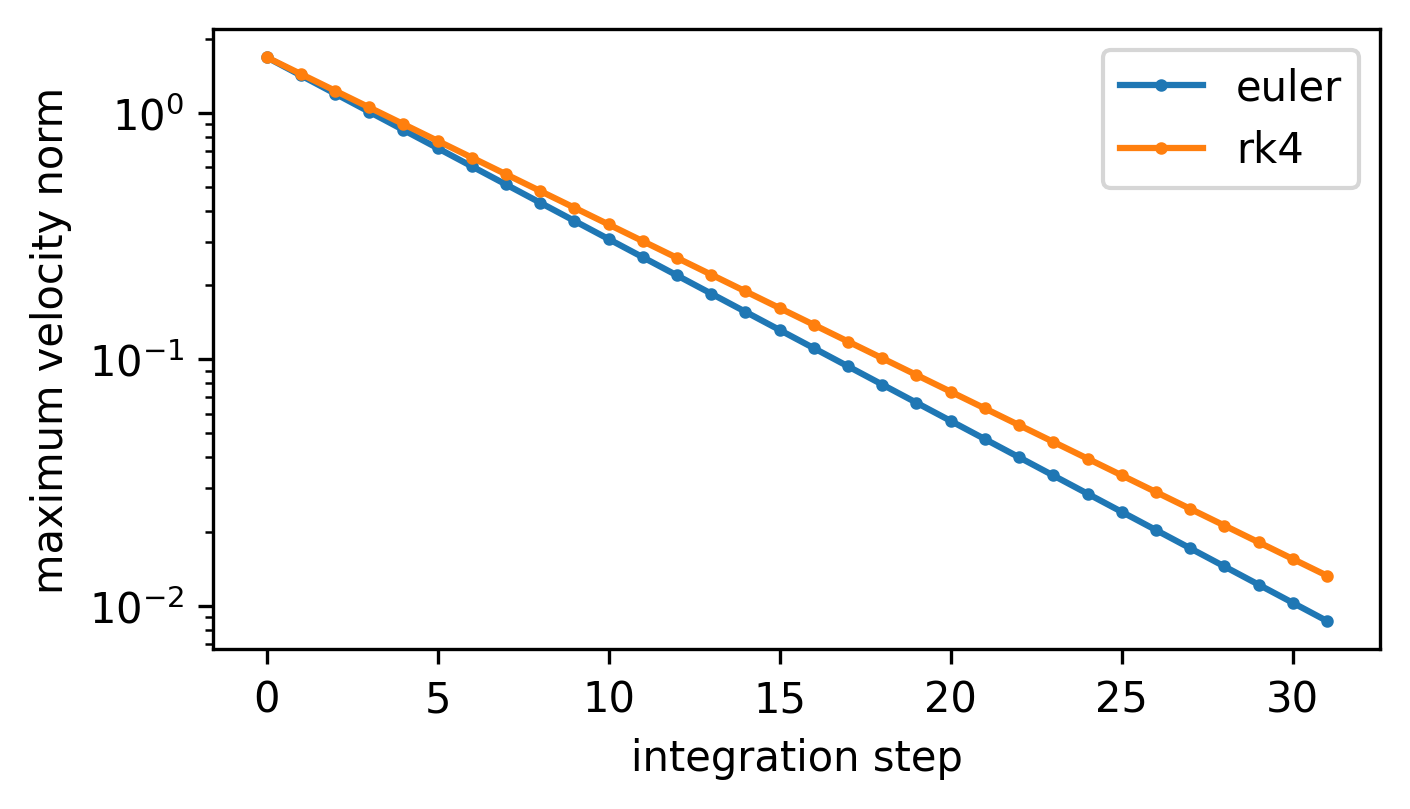

In [5]:
fig, axis = plt.subplots(figsize=(4.8, 2.8))
for name, result in results.items():
    axis.semilogy(
        range(len(result.velocity_norms)),
        result.velocity_norms,
        marker="o",
        markersize=2,
        label=name,
    )
axis.set_xlabel("integration step")
axis.set_ylabel("maximum velocity norm")
axis.legend()
fig.tight_layout()
plt.show()

## 4. Train a Conditioned SILVA Transition

The transition may be learned while the integration rule remains explicit.
For parameters $\theta$, differentiation follows every numerical step:

$$
\frac{d\mathcal L}{d\theta}
=\frac{\partial\mathcal L}{\partial z_K}
\frac{\partial z_K}{\partial\theta}.
$$

Memory therefore grows with the number of retained integration steps. This is
different from an implicit adjoint at a converged algebraic fixed point.

In [6]:
learned = SILVAHomotopyEquilibrium(
    in_dim=2,
    state_dim=6,
    out_dim=2,
    steps=10,
    horizon=4.0,
    integrator="rk4",
)
optimizer = torch.optim.Adam(learned.parameters(), lr=4e-3)
losses = []
for epoch in range(8):
    optimizer.zero_grad()
    prediction = learned(data.condition[:20])
    loss = torch.nn.functional.mse_loss(prediction, data.target[:20])
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

held_out = learned(data.condition[20:], return_result=True)
held_out_loss = torch.nn.functional.mse_loss(held_out.output, data.target[20:])
assert all(torch.isfinite(torch.tensor(losses)))
assert torch.isfinite(held_out_loss)
print("training losses:", losses)
print("held-out loss:", float(held_out_loss))
print("held-out terminal residual:", held_out.terminal_residual)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


training losses: [4.247847557067871, 4.210358619689941, 4.173163414001465, 4.136268615722656, 4.099670886993408, 4.063342571258545, 4.027235984802246, 3.9912993907928467]
held-out loss: 3.668966293334961
held-out terminal residual: 0.03146997466683388


## 5. Choosing the Horizon and Integrator

For the affine example, endpoint error contains the finite-horizon factor
$e^{-(1-a)T_f}$. Increasing the number of steps reduces discretization error,
whereas increasing the horizon reduces truncation error. These controls solve
different problems.

| Control | Primary effect | Cost |
|---|---|---|
| larger horizon | gets closer to a stationary state | may require more steps for accuracy |
| more steps | reduces integration error | more transition evaluations and memory |
| Euler | transparent first-order path | smaller stable step sizes |
| RK4 | higher accuracy per step | four transition evaluations per step |

In [7]:
factory_model = silva_equilibrium_model(
    "silva_homotopy_equilibrium",
    in_dim=2,
    state_dim=4,
    out_dim=2,
    steps=4,
    horizon=2.0,
)
factory_output = factory_model(data.condition[:2])
assert factory_output.shape == (2, 2)
print(type(factory_model).__name__)

SILVAHomotopyEquilibrium


## 6. Practical Guidance

Report the task loss, terminal fixed-point residual, horizon, number of steps,
integrator, and transition evaluations. A low supervised loss does not imply
that the terminal state is near equilibrium. A low terminal residual does not
show that the continuous path matches measured dynamics.

The affine dataset verifies the path equations exactly. Reproducing the cited
vision experiments requires their architecture, data augmentation, schedules,
and evaluation protocol [46].

## Where to Go Next

| Question | Page |
| --- | --- |
| How are the analytic homotopy pairs constructed? | [Dataset-Backed Equilibrium Labs](https://jseluis.github.io/silva-networks/learn/frontier-dataset-labs/#affine-homotopy-pairs) |
| How does the residual flow retain the SILVA fixed point? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/#silva-homotopy-equilibrium) |
| Which homotopy dataset objects are public? | [Recent Dataset API](https://jseluis.github.io/silva-networks/api/frontier_data/) |
